
# Regresión Lineal: Ejemplos Prácticos

Este notebook incluye dos ejemplos de **regresión lineal**:

1. **Regresión Lineal Simple**: Estudiar cómo influye la **estatura del padre** en la **estatura del hijo**.  
2. **Regresión Lineal Múltiple**: Investigar los factores que influyen en la **presión arterial** (edad, peso y nivel de ejercicio).

Incluiremos:  
- Exploración y análisis de datos  
- Creación de modelos de machine learning  
- División en entrenamiento y prueba  
- Evaluación (MAE, MSE, R², varianza explicada)  
- Cálculo de residuos  
- Predicciones y visualización (2D y 3D)  


## 1. Importación de librerías

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score


## 2. Ejemplo de Regresión Lineal Simple: Estatura Padre e Hijo

In [ ]:

# Generación de datos ficticios para estaturas
np.random.seed(42)
padre = np.random.normal(170, 7, 100)  # altura padre en cm
hijo = padre * 0.5 + np.random.normal(80, 5, 100)  # altura hijo en cm con ruido

df_simple = pd.DataFrame({'Padre': padre, 'Hijo': hijo})
df_simple.head()
df_simple.corr()


,Padre,Hijo
Padre,1.000000,0.471858
Hijo,0.471858,1.000000


In [ ]:
df_simple.head()

,Padre,Hijo
0,173.476999,159.661646
1,169.032150,162.412848
2,174.533820,165.553337
3,180.661209,166.319218
4,168.360926,163.374035


Descripción estadística:
            Padre        Hijo
count  100.000000  100.000000
mean   169.273074  164.748060
std      6.357179    5.357718
min    151.661784  153.004126
25%    165.793660  161.106680
50%    169.111306  164.666157
75%    172.841664  168.289746
max    182.965947  179.958174


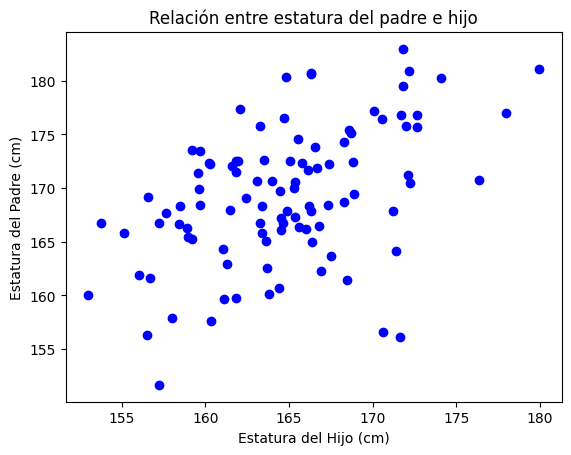

In [ ]:

print("Descripción estadística:")
print(df_simple.describe())

plt.scatter(df_simple['Hijo'], df_simple['Padre'], color='blue')
plt.xlabel("Estatura del Hijo (cm)")
plt.ylabel("Estatura del Padre (cm)")
plt.title("Relación entre estatura del padre e hijo")
plt.show()


In [ ]:

X = df_simple[['Padre']]
y = df_simple['Hijo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)


Intercepto: 97.25396231515951
Coeficiente: [0.39893513]

Evaluación del modelo (Regresión Simple):
MAE: 3.693575260361402
MSE: 21.82121530936312
R²: 0.1758582510053357
Varianza explicada: 0.17700679685008458


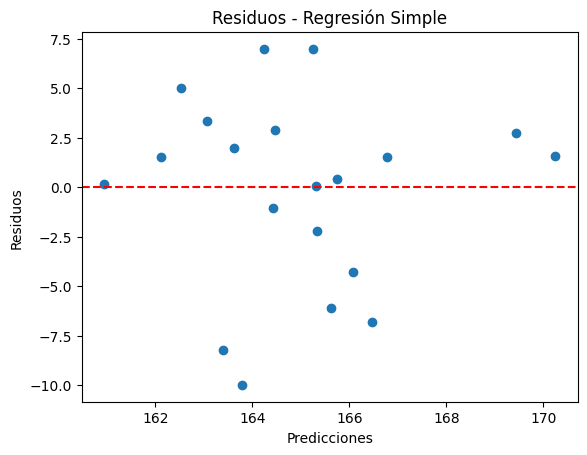

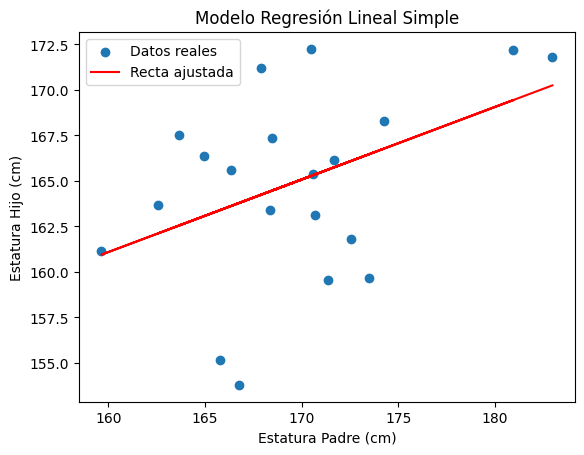

In [ ]:

print("Intercepto:", model_simple.intercept_)
print("Coeficiente:", model_simple.coef_)

print("\nEvaluación del modelo (Regresión Simple):")
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("MSE:", mean_squared_error(y_test, y_pred_simple))
print("R²:", r2_score(y_test, y_pred_simple))
print("Varianza explicada:", explained_variance_score(y_test, y_pred_simple))

residuos = y_test - y_pred_simple
plt.scatter(y_pred_simple, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Simple")
plt.show()

plt.scatter(X_test, y_test, label="Datos reales")
plt.plot(X_test, y_pred_simple, color='red', label="Recta ajustada")
plt.xlabel("Estatura Padre (cm)")
plt.ylabel("Estatura Hijo (cm)")
plt.legend()
plt.title("Modelo Regresión Lineal Simple")
plt.show()


## 3. Ejemplo de Regresión Lineal Múltiple: Factores que influyen en la presión arterial

In [ ]:

# Generación de datos ficticios para presión arterial
np.random.seed(42)
edad = np.random.randint(20, 70, 100)
peso = np.random.randint(50, 100, 100)
ejercicio = np.random.randint(0, 300, 100)

presion = 0.5*edad + 0.8*peso - 0.05*ejercicio + np.random.normal(50, 10, 100)

df_multiple = pd.DataFrame({
    'Edad': edad,
    'Peso': peso,
    'Ejercicio': ejercicio,
    'Presion': presion
})
df_multiple.head()


,Edad,Peso,Ejercicio,Presion
0,58,58,159,116.678983
1,48,73,95,131.061520
2,34,50,232,98.166908
3,62,93,179,154.721832
4,27,57,112,103.630019


Descripción estadística:
             Edad        Peso   Ejercicio     Presion
count  100.000000  100.000000  100.000000  100.000000
mean    44.070000   74.450000  156.610000  124.204628
std     14.447575   14.078693   73.220836   17.688715
min     20.000000   50.000000    1.000000   84.171750
25%     33.000000   61.750000  111.750000  110.893224
50%     43.000000   76.500000  150.500000  123.822718
75%     58.000000   86.000000  209.500000  137.779203
max     69.000000   98.000000  297.000000  172.589441


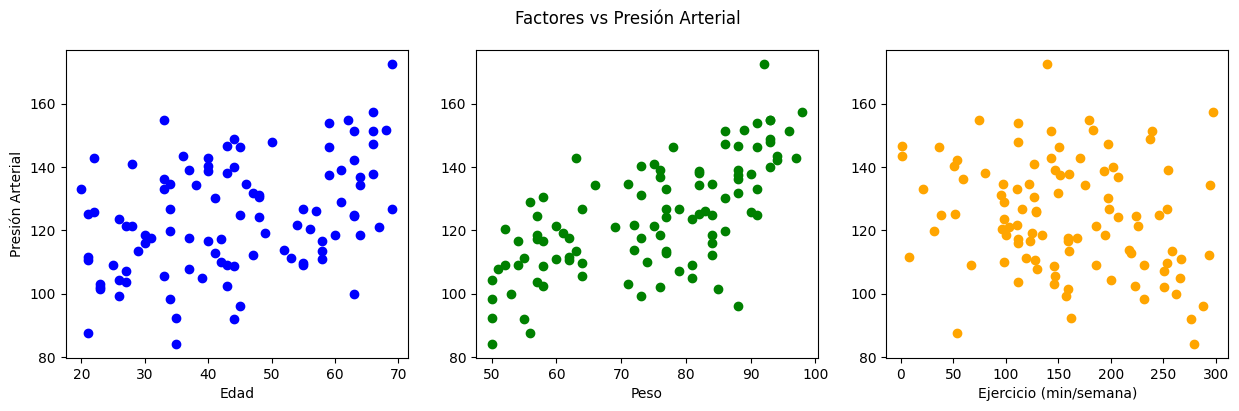

In [ ]:

print("Descripción estadística:")
print(df_multiple.describe())

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].scatter(df_multiple['Edad'], df_multiple['Presion'], color='blue')
axs[0].set_xlabel("Edad")
axs[0].set_ylabel("Presión Arterial")

axs[1].scatter(df_multiple['Peso'], df_multiple['Presion'], color='green')
axs[1].set_xlabel("Peso")

axs[2].scatter(df_multiple['Ejercicio'], df_multiple['Presion'], color='orange')
axs[2].set_xlabel("Ejercicio (min/semana)")

plt.suptitle("Factores vs Presión Arterial")
plt.show()


In [ ]:

X = df_multiple[['Edad', 'Peso', 'Ejercicio']]
y = df_multiple['Presion']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

y_pred_multiple = model_multiple.predict(X_test)


Intercepto: 54.89109966442783
Coeficientes: [ 0.47965348  0.76012695 -0.05401439]

Evaluación del modelo (Regresión Múltiple):
MAE: 8.738503682409936
MSE: 130.8547494471737
R²: 0.6638812223242084
Varianza explicada: 0.6639996353778317


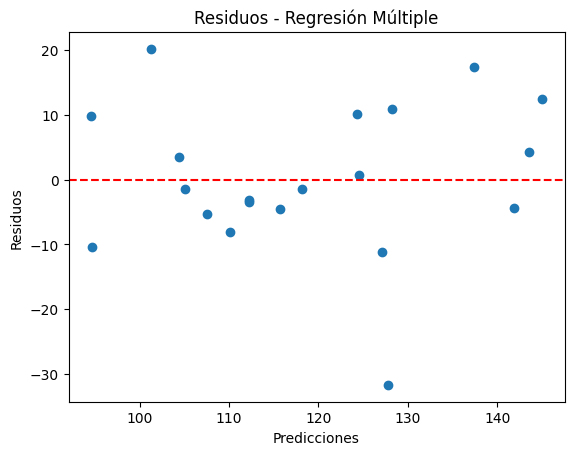

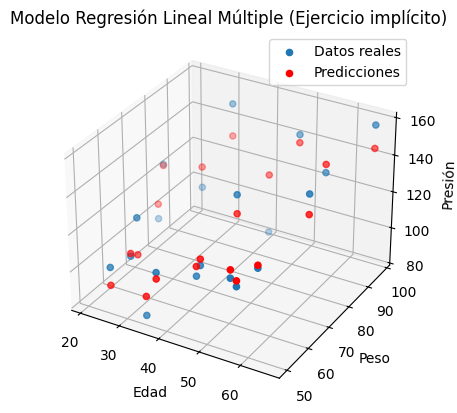

In [ ]:

print("Intercepto:", model_multiple.intercept_)
print("Coeficientes:", model_multiple.coef_)

print("\nEvaluación del modelo (Regresión Múltiple):")
print("MAE:", mean_absolute_error(y_test, y_pred_multiple))
print("MSE:", mean_squared_error(y_test, y_pred_multiple))
print("R²:", r2_score(y_test, y_pred_multiple))
print("Varianza explicada:", explained_variance_score(y_test, y_pred_multiple))

residuos = y_test - y_pred_multiple
plt.scatter(y_pred_multiple, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Múltiple")
plt.show()

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test['Edad'], X_test['Peso'], y_test, label="Datos reales")
ax.scatter(X_test['Edad'], X_test['Peso'], y_pred_multiple, color='red', label="Predicciones")
ax.set_xlabel("Edad")
ax.set_ylabel("Peso")
ax.set_zlabel("Presión")
plt.title("Modelo Regresión Lineal Múltiple (Ejercicio implícito)")
plt.legend()
plt.show()

# presion = edad*0.47+peso*0.76+ejercicio* (-0.05) + 54.89

#presion = 36*0.47+82*0.76+ 300* (-0.05) +54.89

#presion = 150



